Creating decision variables...
Created 240 production variables
Created 240 processing variables
Created 120 setup variables
Created 300 inventory variables
Creating objective function...
Objective function created: Maximize (Revenue - Production Costs - Setup Costs - Inventory Costs - Backorder Penalties)
Creating constraints...
Created 3084 constraints
Solving MILP model...
Problem size: 1020 variables, 3084 constraints
Solution Status: Optimal
Optimal Objective Value: $-4756.80

OPTIMIZATION RESULTS SUMMARY
Total Profit: $-4756.80
Total Production: {0: 0, 1: 0}
Total Sales: {0: 0, 1: 0}
Demand Fulfillment: {0: 0.0, 1: 0.0}

Production Schedule by Machine:

Machine 0:
  Product 1: 16.0 batches = 64.0 units

Machine 1:

Machine 2:

Machine 3:


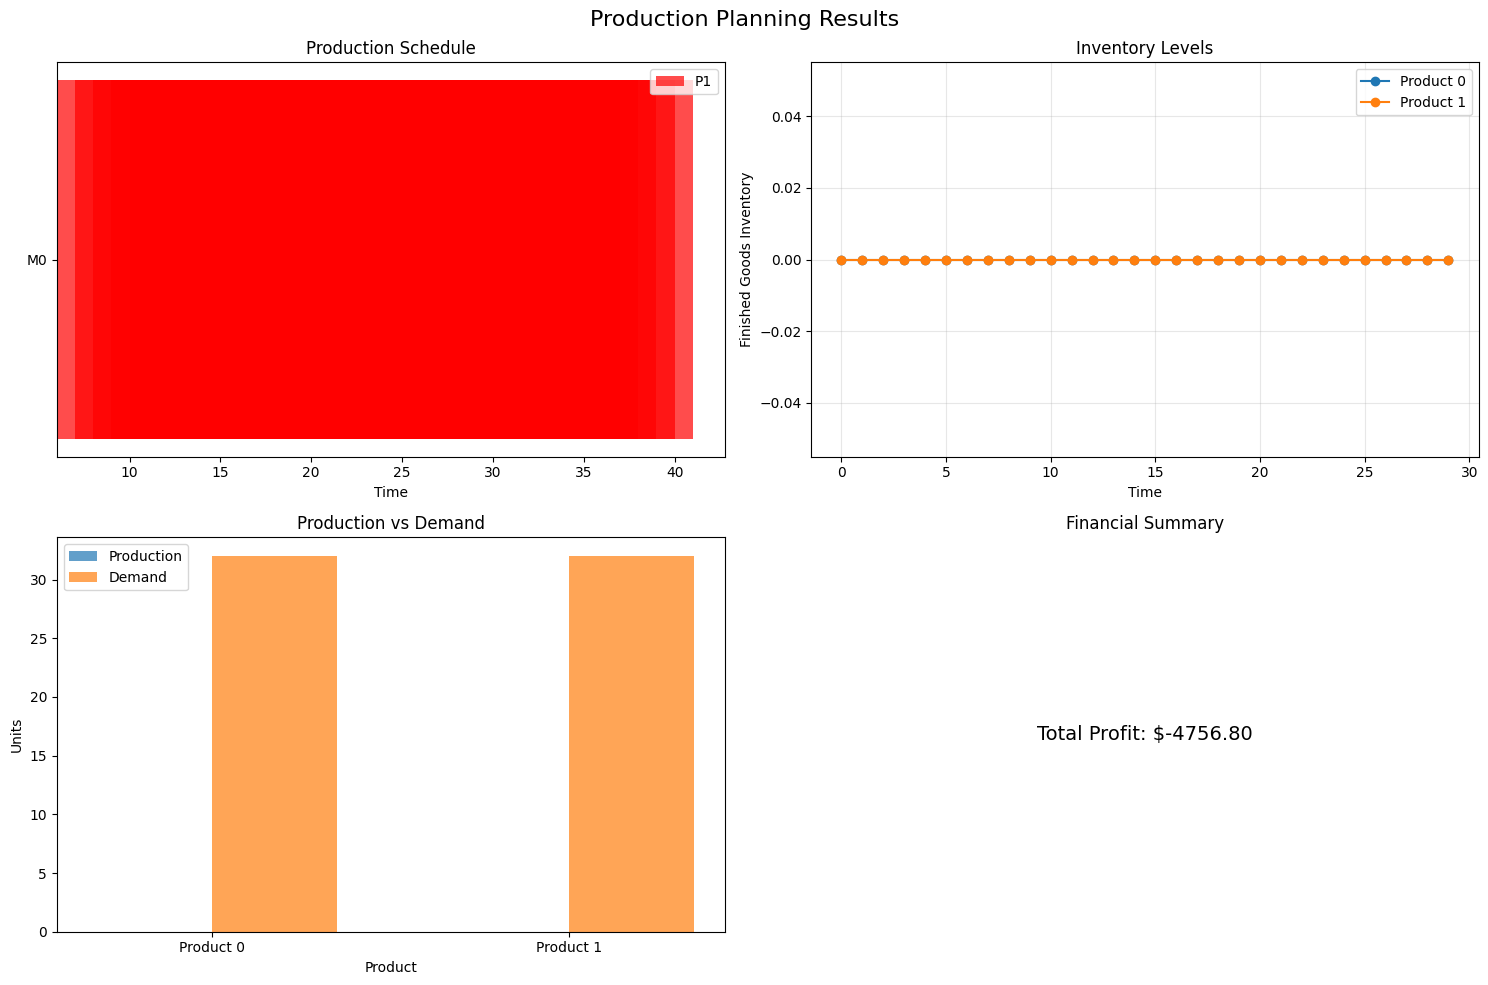

In [ ]:
import pulp
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, Any
#import seaborn as sns

# <<< NEW: bring in the same config factory used by the simulation
def make_common_config(mode: str = "ALL_AT_T0", H: int = 100) -> Dict[str, Any]:
    common = {
        'time_horizon': H,
        'machines': [0, 1, 2, 3],
        'products': [0, 1],
        'processing_times': {
            0: {0: 16, 1: 20},
            1: {0: 2,  1: 2},
            2: {0: 16, 1: 20},
            3: {0: 2,  1: 2},
        },
        'batch_sizes': {0: 4, 1: 1, 2: 4, 3: 1},
        'setup_times': {
            0: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}},
            1: {0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}},
            2: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}},
            3: {0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}},
        },
        'revenue_per_unit': {0: 50, 1: 60},
        'production_cost': {
            0: {0: 8,  1: 10},
            1: {0: 4,  1: 4},
            2: {0: 8,  1: 10},
            3: {0: 4,  1: 4},
        },
        'setup_cost': {0: 0, 1: 20, 2: 0, 3: 20},
        'inventory_cost_per_unit': {0: 0.5, 1: 0.6},
        'backorder_cost_per_unit': {0: 15, 1: 18},
        'initial_inventory': {
            0: {0: 0, 1: 0},
            1: {0: 0, 1: 0},
            2: {0: 0, 1: 0},
            3: {0: 0, 1: 0},
            'finished': {0: 0, 1: 0},
        },
        'arrivals_schedule': {},
        'demand_schedule': {},
    }

    TOTAL_0, TOTAL_1 = 64, 64
    def zero(n: int): return [0]*n

    if mode.upper() == "ALL_AT_T0":
        arr0 = zero(H); arr1 = zero(H); dem0 = zero(H); dem1 = zero(H)
        arr0[0] = TOTAL_0; arr1[0] = TOTAL_1
        dem0[0] = TOTAL_0; dem1[0] = TOTAL_1
    elif mode.upper() == "UNIFORM":
        base0, r0 = divmod(TOTAL_0, H)
        base1, r1 = divmod(TOTAL_1, H)
        arr0 = [base0 + (1 if t < r0 else 0) for t in range(H)]
        arr1 = [base1 + (1 if t < r1 else 0) for t in range(H)]
        dem0 = arr0[:]; dem1 = arr1[:]
    else:
        raise ValueError("mode must be ALL_AT_T0 or UNIFORM")

    common['arrivals_schedule'] = {0: arr0, 1: arr1}
    common['demand_schedule']   = {0: dem0, 1: dem1}
    # keep totals for reporting (optional)
    common['demand'] = {0: TOTAL_0, 1: TOTAL_1}
    return common
# <<< END NEW

class ProductionPlanningMILP:
    """
    Mixed Integer Linear Programming model for 4-machine production line
    with revenue maximization objective
    """
    
    def __init__(self, config: Optional[Dict[str, Any]] = None):
        """
        Initialize the MILP model with configurable parameters
        """
        # Default configuration - all parameters are configurable
        self.default_config = {
            # Time horizon
            'time_horizon': 50,
            
            # Machine parameters
            'machines': [0, 1, 2, 3],
            'products': [0, 1],
            
            # Processing times [machine][product]
            'processing_times': {
                0: {0: 16, 1: 20},  # Machine 0: batch processor
                1: {0: 2, 1: 2},    # Machine 1: individual processor  
                2: {0: 16, 1: 20},  # Machine 2: batch processor
                3: {0: 2, 1: 2}     # Machine 3: individual processor
            },
            
            # Batch sizes for each machine
            'batch_sizes': {0: 4, 1: 1, 2: 4, 3: 1},
            
            # Setup times [machine][from_product][to_product]
            'setup_times': {
                0: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}},  # No setup for batch machines
                1: {0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}},  # Setup required
                2: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}},  # No setup for batch machines  
                3: {0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}}   # Setup required
            },
            
            # Demand for each product
            'demand': {0: 64, 1: 64},
            
            # Economic parameters
            'revenue_per_unit': {0: 50, 1: 60},  # Revenue per unit sold
            'production_cost': {  # Cost per batch processed
                0: {0: 8, 1: 10},   # Machine 0 costs
                1: {0: 4, 1: 4},    # Machine 1 costs  
                2: {0: 8, 1: 10},   # Machine 2 costs
                3: {0: 4, 1: 4}     # Machine 3 costs
            },
            'setup_cost': {  # Cost per setup operation
                0: 0, 1: 20, 2: 0, 3: 20
            },
            'inventory_cost_per_unit': {0: 0.5, 1: 0.6},  # Per unit per period
            'backorder_cost_per_unit': {0: 15, 1: 18},    # Penalty for unmet demand
            
            # Initial conditions
            'initial_inventory': {
                0: {0: 64, 1: 64},  # Queue 0 starts with all raw materials
                1: {0: 0, 1: 0},    # Other queues start empty
                2: {0: 0, 1: 0},
                3: {0: 0, 1: 0},
                'finished': {0: 0, 1: 0}  # Finished goods inventory
            }
        }
        
        # Update with user configuration
        self.config = self.default_config.copy()
        if config:
            self.config.update(config)
            
        # Extract commonly used parameters
        self.T = range(self.config['time_horizon'])
        self.M = self.config['machines']  
        self.P = self.config['products']
        
        # Initialize the optimization problem
        self.prob = pulp.LpProblem("Production_Revenue_Maximization", pulp.LpMaximize)
        
        # Decision variables (will be created in create_variables)
        self.x = {}  # Production variables
        self.y = {}  # Binary processing variables
        self.z = {}  # Setup variables
        self.I = {}  # Inventory variables
        self.S = {}  # Sales variables
        self.B = {}  # Backorder variables
        
    def create_variables(self):
        """
        Create all decision variables for the MILP model
        """
        print("Creating decision variables...")
        
        # Production variables: x[m,j,t] = number of batches of product j started on machine m at time t
        self.x = pulp.LpVariable.dicts("production", [(m, j, t) for m in self.M for j in self.P for t in self.T], lowBound=0, upBound=1, cat='Binary')  # start at most one batch at time t

        
        # Binary processing variables: y[m,j,t] = 1 if product j is processed on machine m at time t
        self.y = pulp.LpVariable.dicts("processing", 
                                     [(m, j, t) for m in self.M for j in self.P for t in self.T],
                                     cat='Binary')
        
        # Setup variables: z[m,i,j,t] = 1 if machine m switches from product i to j at time t
        self.z = pulp.LpVariable.dicts("setup",
                                     [(m, i, j, t) for m in [1, 3] for i in self.P 
                                      for j in self.P for t in self.T if i != j],
                                     cat='Binary')
        
        # Inventory variables: I[m,j,t] = inventory of product j before machine m at end of period t
        self.I = pulp.LpVariable.dicts("inventory",
                                     [(m, j, t) for m in self.M + ['finished'] for j in self.P for t in self.T],
                                     lowBound=0, cat='Continuous')
        
        # Sales variables: S[j,t] = units of product j sold at time t
        self.S = pulp.LpVariable.dicts("sales",
                                     [(j, t) for j in self.P for t in self.T],
                                     lowBound=0, cat='Continuous')
        
        # Backorder variables: B[j,t] = unfulfilled demand for product j at time t
        self.B = pulp.LpVariable.dicts("backorder",
                                     [(j, t) for j in self.P for t in self.T],
                                     lowBound=0, cat='Continuous')
        
        print(f"Created {len(self.x)} production variables")
        print(f"Created {len(self.y)} processing variables") 
        print(f"Created {len(self.z)} setup variables")
        print(f"Created {len(self.I)} inventory variables")
        
    def create_objective_function(self):
        """
        Create the revenue maximization objective function
        
        Maximize: Total Revenue - Production Costs - Setup Costs - Inventory Costs - Backorder Penalties
        """
        print("Creating objective function...")
        
        # Revenue from sales
        revenue = pulp.lpSum([
            self.config['revenue_per_unit'][j] * self.S[(j, t)]
            for j in self.P for t in self.T
        ])
        
        # Production costs (cost per batch processed)
        production_costs = pulp.lpSum([
            self.config['production_cost'][m][j] * self.x[(m, j, t)]
            for m in self.M for j in self.P for t in self.T
        ])
        
        # Setup costs (only for machines 1 and 3)
        setup_costs = pulp.lpSum([
            self.config['setup_cost'][m] * self.z[(m, i, j, t)]
            for m in [1, 3] for i in self.P for j in self.P for t in self.T if i != j
        ])
        
        # Inventory holding costs
        inventory_costs = pulp.lpSum([
            self.config['inventory_cost_per_unit'][j] * self.I[(m, j, t)]
            for m in self.M + ['finished'] for j in self.P for t in self.T
        ])
        
        # Backorder penalty costs
        backorder_costs = pulp.lpSum([
            self.config['backorder_cost_per_unit'][j] * self.B[(j, t)]
            for j in self.P for t in self.T
        ])
        
        # Complete objective function
        self.prob += (revenue - production_costs - setup_costs - inventory_costs - backorder_costs,
                     "Total_Profit")
        
        print("Objective function created: Maximize (Revenue - Production Costs - Setup Costs - Inventory Costs - Backorder Penalties)")
        
    def create_constraints(self):
        """
        Create all constraints for the MILP model
        """
        print("Creating constraints...")
        
        # 1. MACHINE CAPACITY CONSTRAINTS
        # Each machine can process at most one product type at any time
        for m in self.M:
            for t in self.T:
                self.prob += (
                    pulp.lpSum([self.y[(m, j, t)] for j in self.P]) <= 1,
                    f"Machine_Capacity_M{m}_T{t}"
                )
        
        # 2. PRODUCTION-PROCESSING LINKAGE CONSTRAINTS  
        # If x[m,j,t] > 0, then y[m,j,tau] = 1 for tau in processing period
        for m in self.M:
            for j in self.P:
                for t in self.T:
                    processing_time = self.config['processing_times'][m][j]
                    batch_size = self.config['batch_sizes'][m]
                    
                    # If a batch starts at t, the machine must be busy with that product for PT periods
                    self.prob += (
                        self.y[(m, j, t)] >= self.x[(m, j, t)],
                        f"StartImpliesBusyAtStart_M{m}_P{j}_T{t}"
                    )
                    for tau in range(t, min(t + processing_time, len(self.T))):
                        self.prob += (
                            self.y[(m, j, tau)] >= self.x[(m, j, t)],
                            f"ProcessingWindow_M{m}_P{j}_T{t}_Tau{tau}"
                    )

        
        # 3. SETUP CONSTRAINTS (for machines 1 and 3 only)
        for m in [1, 3]:
            for t in range(1, len(self.T)):
                for i in self.P:
                    for j in self.P:
                        if i != j:
                            # Setup is triggered when switching from product i to j
                            self.prob += (
                                self.z[(m, i, j, t)] >= self.y[(m, j, t)] - self.y[(m, i, t-1)],
                                f"Setup_Trigger_M{m}_P{i}_to_P{j}_T{t}"
                            )
                            # Upper bounds so z can only be 1 when both sides are “on”/“off” as appropriate
                            self.prob += self.z[(m,i,j,t)] <= self.y[(m,j,t)],       f"SetupUB_now_M{m}_i{i}_j{j}_T{t}"
                            self.prob += self.z[(m,i,j,t)] <= self.y[(m,i,t-1)],     f"SetupUB_prev_M{m}_i{i}_j{j}_T{t}"

        
        # 4. INVENTORY FLOW BALANCE CONSTRAINTS
        for j in self.P:
            for t in self.T:
                # Queue 0 (raw materials): Initial inventory + arrivals - departures
                if t == 0:
                    self.prob += (
                        self.I[(0, j, t)] == self.config['initial_inventory'][0][j] - 
                        self.x[(0, j, t)] * self.config['batch_sizes'][0],
                        f"Inventory_Queue0_P{j}_T{t}"
                    )
                else:
                    self.prob += (
                        self.I[(0, j, t)] == self.I[(0, j, t-1)] - 
                        self.x[(0, j, t)] * self.config['batch_sizes'][0],
                        f"Inventory_Queue0_P{j}_T{t}"
                    )
                
                # Intermediate queues (1, 2, 3)
                for m in [1, 2, 3]:
                    p_prev = self.config['processing_times'][m-1][j]
                    last_start_that_finishes_by_t = t - (p_prev - 1)
                    arrivals = pulp.lpSum([
                        self.x[(m-1, j, tau)] * self.config['batch_sizes'][m-1]
                        for tau in range(0, max(0, last_start_that_finishes_by_t) + 1)
                    ])

                    departures = self.x[(m, j, t)] * self.config['batch_sizes'][m]
                    
                    if t == 0:
                        self.prob += (
                            self.I[(m, j, t)] == self.config['initial_inventory'][m][j] + arrivals - departures,
                            f"Inventory_Queue{m}_P{j}_T{t}"
                        )
                    else:
                        self.prob += (
                            self.I[(m, j, t)] == self.I[(m, j, t-1)] + arrivals - departures,
                            f"Inventory_Queue{m}_P{j}_T{t}"
                        )
                
                # Finished goods inventory
                p3 = self.config['processing_times'][3][j]
                last_start_that_finishes_by_t = t - (p3 - 1)
                finished_arrivals = pulp.lpSum([
                    self.x[(3, j, tau)] * self.config['batch_sizes'][3]
                    for tau in range(0, max(0, last_start_that_finishes_by_t) + 1)
                ])

                
                if t == 0:
                    self.prob += (
                        self.I[('finished', j, t)] == self.config['initial_inventory']['finished'][j] + 
                        finished_arrivals - self.S[(j, t)],
                        f"Inventory_Finished_P{j}_T{t}"
                    )
                else:
                    self.prob += (
                        self.I[('finished', j, t)] == self.I[('finished', j, t-1)] + 
                        finished_arrivals - self.S[(j, t)],
                        f"Inventory_Finished_P{j}_T{t}"
                    )
        
        # 5. PRODUCTION CAPACITY CONSTRAINTS
        # Cannot produce more than available inventory in previous queue
        for m in self.M:
            for j in self.P:
                for t in self.T:
                    if t == 0:
                        available_inventory = self.config['initial_inventory'][m][j]
                    else:
                        available_inventory = self.I[(m, j, t-1)]
                    
                    self.prob += (
                        self.x[(m, j, t)] * self.config['batch_sizes'][m] <= available_inventory,
                        f"Production_Capacity_M{m}_P{j}_T{t}"
                    )
        
        # 6. SALES AND DEMAND CONSTRAINTS
        for j in self.P:
            cumulative_demand = 0
            for t in self.T:
                cumulative_demand += self.config['demand'][j] / len(self.T)  # Assume uniform demand arrival
                
                # Sales cannot exceed finished goods inventory
                if t == 0:
                    available_finished = self.config['initial_inventory']['finished'][j]
                else:
                    available_finished = self.I[('finished', j, t-1)]
                
                # Track cumulative sales and backorders
                cumulative_sales = pulp.lpSum([self.S[(j, tau)] for tau in range(t + 1)])
                cumulative_backorders = pulp.lpSum([self.B[(j, tau)] for tau in range(t + 1)])
                
                # Demand balance: cumulative_demand = cumulative_sales + cumulative_backorders
                self.prob += (
                    cumulative_sales + cumulative_backorders >= cumulative_demand,
                    f"Demand_Balance_P{j}_T{t}"
                )
        
        print(f"Created {len(self.prob.constraints)} constraints")
        
    def solve_model(self):
        """
        Solve the MILP model and return results
        """
        print("Solving MILP model...")
        print(f"Problem size: {len(self.prob.variables())} variables, {len(self.prob.constraints)} constraints")
        
        # Solve the problem
        solver = pulp.PULP_CBC_CMD(msg=True)  # CBC accepts bool; Pylance expects bool
        self.prob.solve(solver)
        
        # Check solution status
        print(f"Solution Status: {pulp.LpStatus[self.prob.status]}")
        
        if self.prob.status == pulp.LpStatusOptimal:
            print(f"Optimal Objective Value: ${self.prob.objective.value():.2f}")
            return True
        else:
            print("No optimal solution found!")
            return False
    
    def analyze_results(self):
        """
        Analyze and display the optimization results
        """
        if self.prob.status != pulp.LpStatusOptimal:
            print("Cannot analyze results - no optimal solution found")
            return None
        
        results = {
            'objective_value': self.prob.objective.value(),
            'production_schedule': {},
            'inventory_levels': {},
            'sales_schedule': {},
            'setup_schedule': {},
            'summary': {}
        }
        
        # Extract production schedule
        for m in self.M:
            results['production_schedule'][m] = {}
            for j in self.P:
                results['production_schedule'][m][j] = {}
                for t in self.T:
                    value = self.x[(m, j, t)].value()
                    if value and value > 0:
                        results['production_schedule'][m][j][t] = value
        
        # Extract inventory levels
        for location in self.M + ['finished']:
            results['inventory_levels'][location] = {}
            for j in self.P:
                results['inventory_levels'][location][j] = {}
                for t in self.T:
                    value = self.I[(location, j, t)].value()
                    if value is not None:
                        results['inventory_levels'][location][j][t] = value
        
        # Extract sales schedule
        for j in self.P:
            results['sales_schedule'][j] = {}
            for t in self.T:
                value = self.S[(j, t)].value()
                if value and value > 0:
                    results['sales_schedule'][j][t] = value
        
        # Calculate summary statistics
        total_production = {}
        total_sales = {}
        for j in self.P:
            total_production[j] = sum([
                self.x[(3, j, t)].value() * self.config['batch_sizes'][3] 
                for t in self.T if self.x[(3, j, t)].value()
            ])
            total_sales[j] = sum([
                self.S[(j, t)].value() for t in self.T if self.S[(j, t)].value()
            ])
        
        results['summary'] = {
            'total_profit': self.prob.objective.value(),
            'total_production': total_production,
            'total_sales': total_sales,
            'demand_fulfillment': {j: total_sales[j] / self.config['demand'][j] 
                                 for j in self.P}
        }
        
        return results
    
    def display_results(self, results):
        """
        Display formatted results
        """
        print("\n" + "="*60)
        print("OPTIMIZATION RESULTS SUMMARY")
        print("="*60)
        
        print(f"Total Profit: ${results['objective_value']:.2f}")
        print(f"Total Production: {results['summary']['total_production']}")
        print(f"Total Sales: {results['summary']['total_sales']}")
        print(f"Demand Fulfillment: {results['summary']['demand_fulfillment']}")
        
        # Production Schedule Summary
        print("\nProduction Schedule by Machine:")
        for m in self.M:
            print(f"\nMachine {m}:")
            for j in self.P:
                if results['production_schedule'][m][j]:
                    total_batches = sum(results['production_schedule'][m][j].values())
                    total_units = total_batches * self.config['batch_sizes'][m]
                    print(f"  Product {j}: {total_batches} batches = {total_units} units")
    
    def create_visualization(self, results):
        """
        Create visualization of the production schedule and inventory levels
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Production Planning Results', fontsize=16)
        
        # 1. Production Schedule Gantt Chart
        ax1 = axes[0, 0]
        gantt_data = []
        for m in self.M:
            for j in self.P:
                for t, batches in results['production_schedule'][m][j].items():
                    if batches > 0:
                        processing_time = self.config['processing_times'][m][j]
                        gantt_data.append({
                            'Machine': f'M{m}',
                            'Start': t,
                            'Duration': processing_time,
                            'Product': f'P{j}',
                            'Batches': batches
                        })
        
        if gantt_data:
            gantt_df = pd.DataFrame(gantt_data)
            machines = gantt_df['Machine'].unique()
            colors = {'P0': 'blue', 'P1': 'red'}
            
            for i, machine in enumerate(machines):
                machine_data = gantt_df[gantt_df['Machine'] == machine]
                for _, row in machine_data.iterrows():
                    ax1.barh(i, row['Duration'], left=row['Start'], 
                            color=colors[row['Product']], alpha=0.7, 
                            label=row['Product'] if row['Product'] not in ax1.get_legend_handles_labels()[1] else "")
            
            ax1.set_yticks(range(len(machines)))
            ax1.set_yticklabels(machines)
            ax1.set_xlabel('Time')
            ax1.set_title('Production Schedule')
            ax1.legend()
        
        # 2. Inventory Levels
        ax2 = axes[0, 1]
        for j in self.P:
            inventory_data = [results['inventory_levels']['finished'][j].get(t, 0) for t in self.T]
            ax2.plot(self.T, inventory_data, label=f'Product {j}', marker='o')
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Finished Goods Inventory')
        ax2.set_title('Inventory Levels')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 3. Production vs Demand
        ax3 = axes[1, 0]
        products = list(self.P)
        production_values = [results['summary']['total_production'][j] for j in products]
        demand_values = [self.config['demand'][j] for j in products]
        
        x = np.arange(len(products))
        width = 0.35
        
        ax3.bar(x - width/2, production_values, width, label='Production', alpha=0.7)
        ax3.bar(x + width/2, demand_values, width, label='Demand', alpha=0.7)
        ax3.set_xlabel('Product')
        ax3.set_ylabel('Units')
        ax3.set_title('Production vs Demand')
        ax3.set_xticks(x)
        ax3.set_xticklabels([f'Product {j}' for j in products])
        ax3.legend()
        
        # 4. Cost Breakdown (if we can calculate it)
        ax4 = axes[1, 1]
        ax4.text(0.5, 0.5, f'Total Profit: ${results["objective_value"]:.2f}', 
                ha='center', va='center', fontsize=14, transform=ax4.transAxes)
        ax4.set_title('Financial Summary')
        ax4.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        return fig

def main():
    """
    Main function to run the MILP optimization
    """
    # Create custom configuration
    custom_config = {
        'time_horizon': 30,
        'demand': {0: 32, 1: 32},  # Reduced for faster solving
        'revenue_per_unit': {0: 100, 1: 120},  # Higher revenue
        'production_cost': {
            0: {0: 10, 1: 12},
            1: {0: 5, 1: 5},
            2: {0: 10, 1: 12},
            3: {0: 5, 1: 5}
        },
        'setup_cost': {0: 0, 1: 25, 2: 0, 3: 25},
        'inventory_cost_per_unit': {0: 1.0, 1: 1.2},
        'backorder_cost_per_unit': {0: 20, 1: 25}
    }
    
    # Create and solve model
    model = ProductionPlanningMILP(custom_config)
    model.create_variables()
    model.create_objective_function()  
    model.create_constraints()
    
    # Solve the model
    if model.solve_model():
        results = model.analyze_results()
        model.display_results(results)
        model.create_visualization(results)
        return model, results
    else:
        return model, None

if __name__ == "__main__":
    model, results = main()
